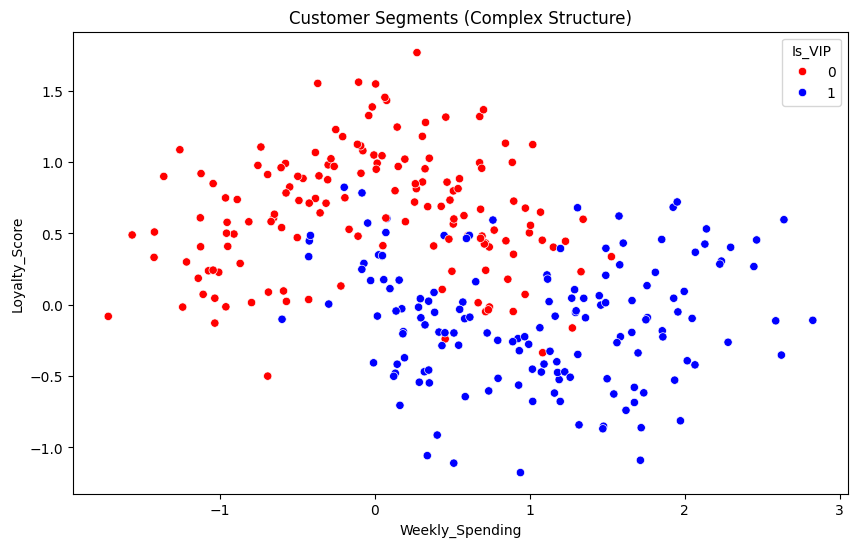

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons # Zorlu veri üretmek için

# 1. Data Generation (Interleaved crescent-shaped data)
# Let's add some noise=0.3 to make the data a bit more realistic 
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Let's convert to DataFrame (for easier explanation and visualization)
df_forest = pd.DataFrame(X, columns=['Weekly_Spending', 'Loyalty_Score'])
df_forest['Is_VIP'] = y

# 2. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weekly_Spending', y='Loyalty_Score', hue='Is_VIP', data=df_forest, palette=['red', 'blue'])
plt.title('Customer Segments (Complex Structure)')
plt.show()

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Single Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 2. Random Forest (Ensemble of 100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models have been trained.")

Both models have been trained.


In [3]:
from sklearn.metrics import accuracy_score

# Single Tree Score
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Random Forest Score
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Single Tree Accuracy: %{tree_acc * 100:.2f}")
print(f"Random Forest Accuracy:   %{rf_acc * 100:.2f}")

Single Tree Accuracy: %85.00
Random Forest Accuracy:   %88.33


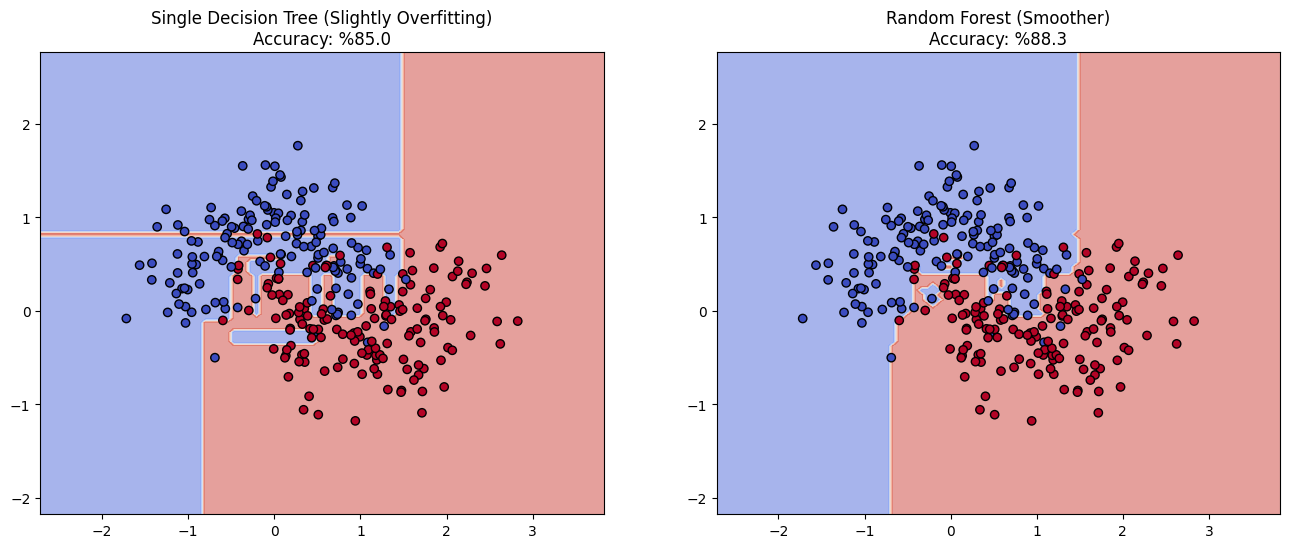

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphic 1: Single Decision Tree ---
DecisionBoundaryDisplay.from_estimator(
    tree_model, X, cmap='coolwarm', alpha=0.5, ax=ax[0], response_method='predict'
)
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
ax[0].set_title(f'Single Decision Tree (Slightly Overfitting)\nAccuracy: %{tree_acc*100:.1f}')

# --- Graphic 2: Random Forest ---
DecisionBoundaryDisplay.from_estimator(
    rf_model, X, cmap='coolwarm', alpha=0.5, ax=ax[1], response_method='predict'
)
ax[1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
ax[1].set_title(f'Random Forest (Smoother)\nAccuracy: %{rf_acc*100:.1f}')

plt.show()

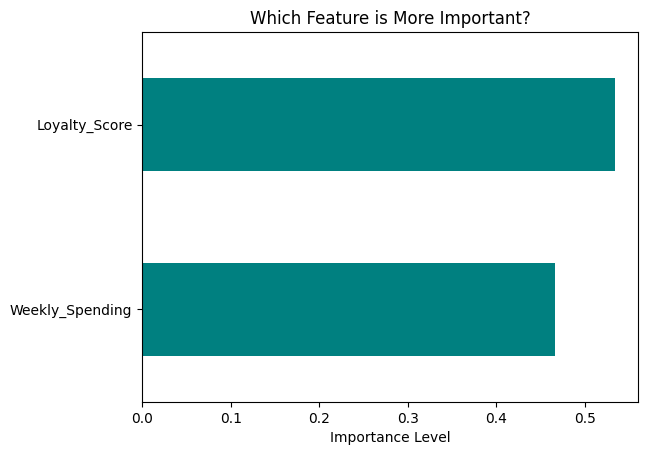

In [5]:
importances = pd.Series(rf_model.feature_importances_, index=['Weekly_Spending', 'Loyalty_Score'])
importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Which Feature is More Important?')
plt.xlabel('Importance Level')
plt.show()